In [18]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [19]:
data=pd.read_csv('train.csv')
#combined=pd.concat([data,data2], ignore_index=True)
data.shape

(2000, 21)

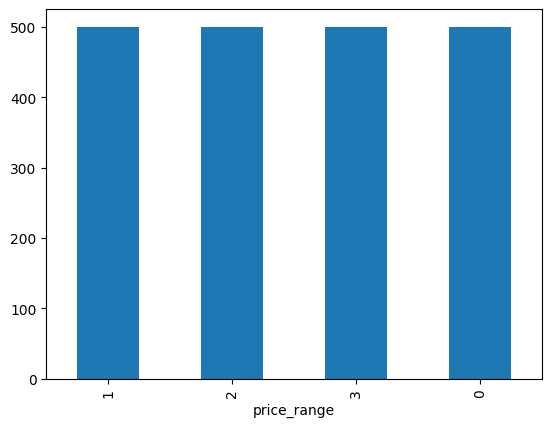

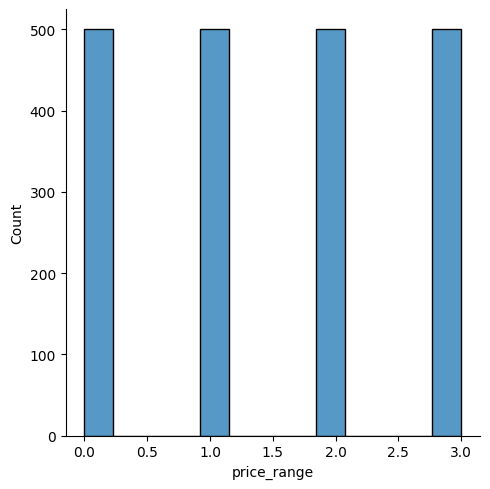

In [20]:

#data analysis.graphing
import seaborn as sns
price_plot=data['price_range'].value_counts().plot(kind='bar')
sns.displot(data['price_range'])
plt.show()

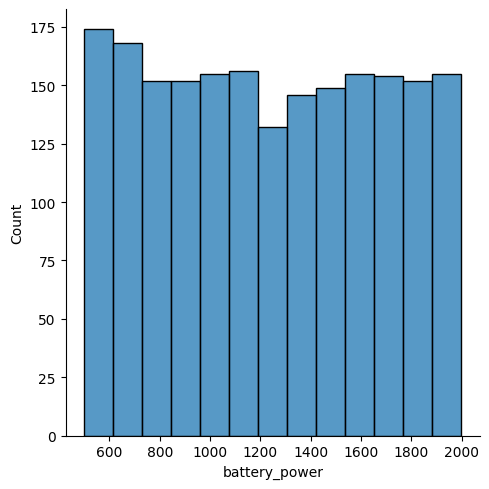

In [21]:
sns.displot(data['battery_power'])

<Axes: xlabel='blue', ylabel='price_range'>

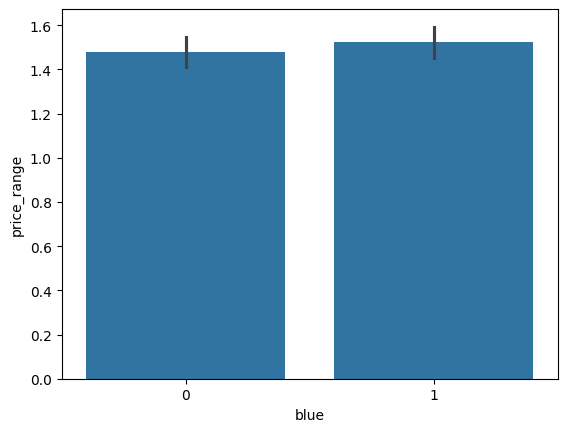

In [22]:
sns.barplot(data=data,x='blue',y='price_range')

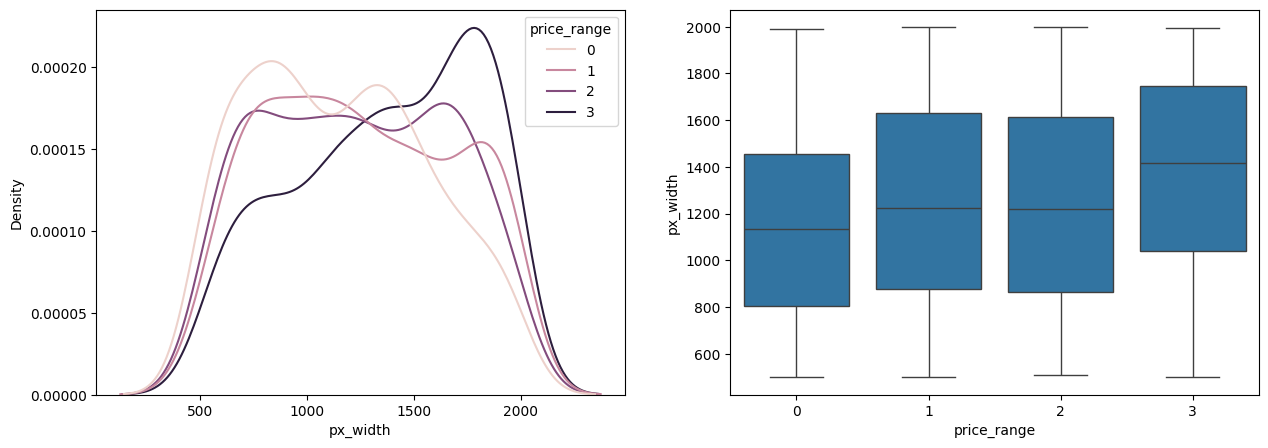

In [23]:
#kde plot for density
fig, axs = plt.subplots(1,2, figsize=(15,5))
sns.kdeplot(data=data, x='px_width', hue='price_range', ax=axs[0])
sns.boxplot(data=data, x='price_range', y='px_width', ax=axs[1])
plt.show()

In [24]:
#features dont show much variation remove them
data.drop(['sc_h', 'sc_w'], axis = 1, inplace = True)


C:\Users\sivar\AppData\Local\Temp\ipykernel_14932\3498054986.py:4: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:pink'` for the same effect.

  sns.countplot(x = col, hue = 'price_range', data = data, ax = ax2, color = 'pink')
C:\Users\sivar\AppData\Local\Temp\ipykernel_14932\3498054986.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Does not Support', 'Support'])
C:\Users\sivar\AppData\Local\Temp\ipykernel_14932\3498054986.py:4: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:pink'` for the same effect.

  sns.countplot(x = col, hue = 'price_range', data = data, ax = ax2, color = 'pink')
C:\Users\sivar\AppData\Local\Temp\ipykernel_14932\3498054986.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of tick

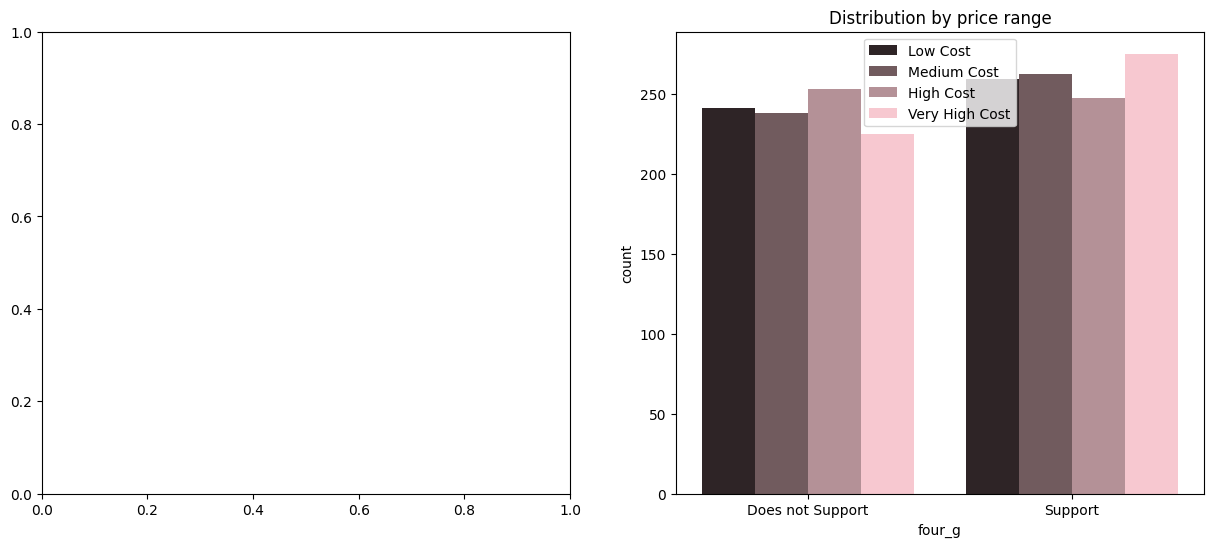

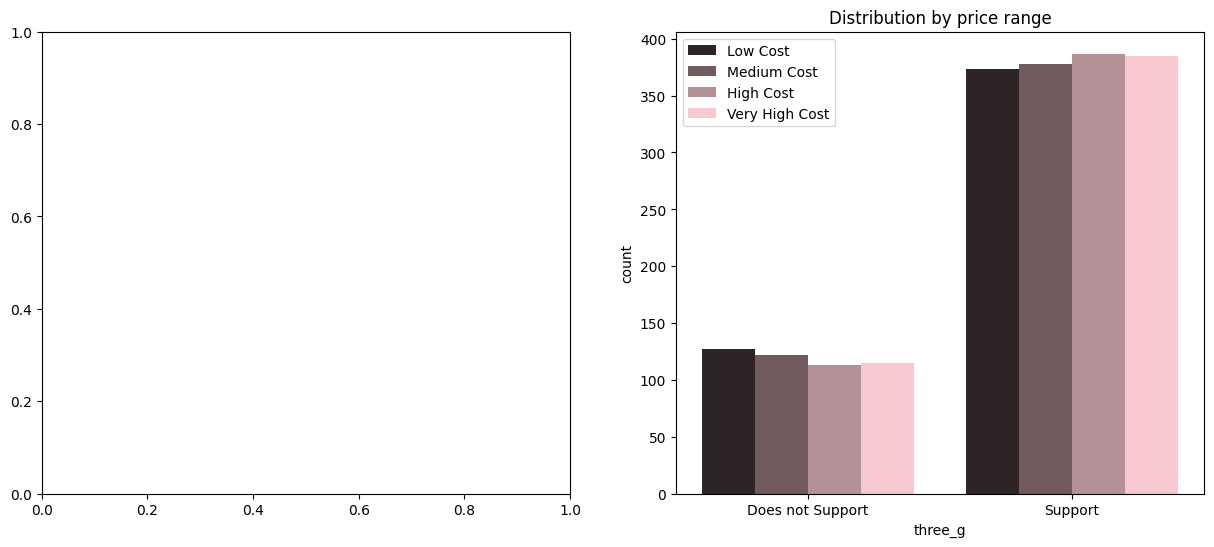

In [ ]:
binary_features = [ 'four_g', 'three_g']
for col in binary_features:
  fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (15, 6))
  sns.countplot(x = col, hue = 'price_range', data = data, ax = ax2, color = 'pink')
  ax2.set_title('Distribution by price range')
  ax2.set_xlabel(col)
  ax2.legend(['Low Cost', 'Medium Cost', 'High Cost', 'Very High Cost'])
  ax2.set_xticklabels(['Does not Support', 'Support'])
  

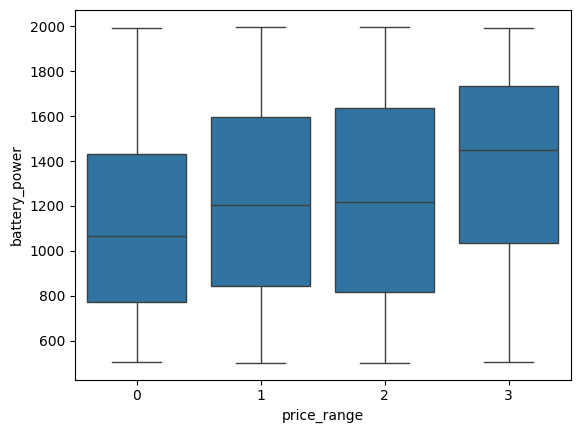

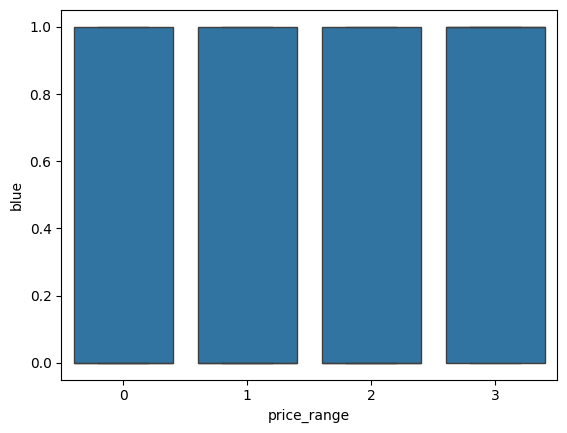

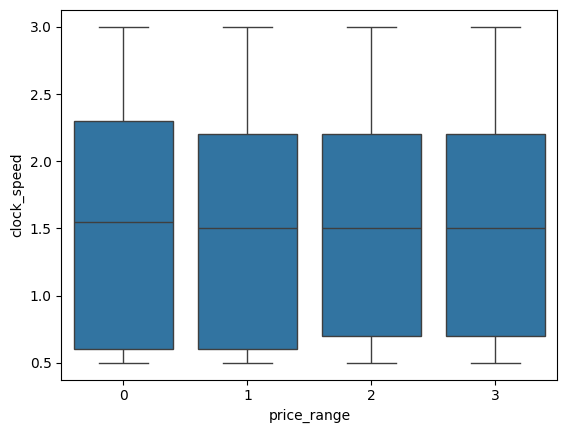

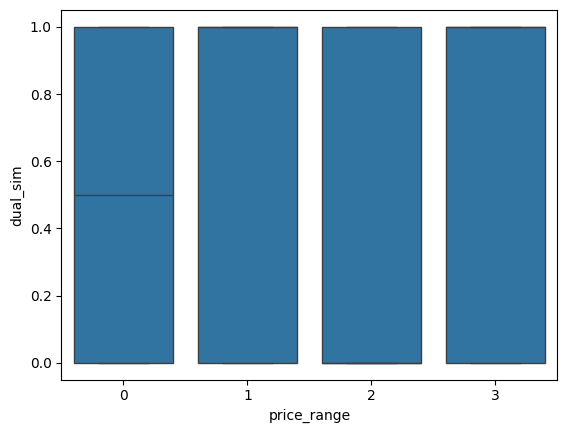

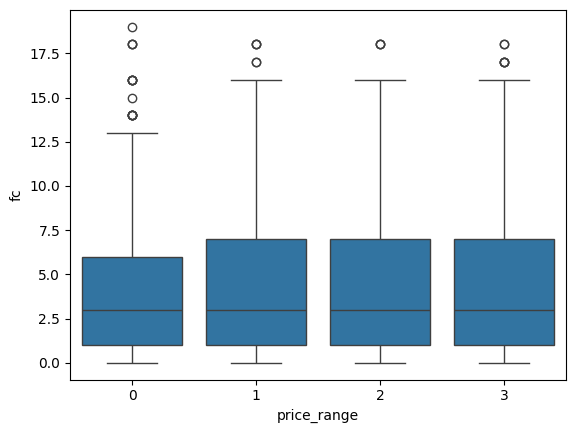

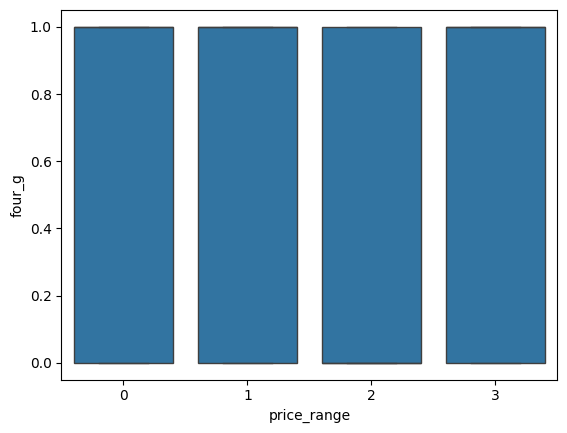

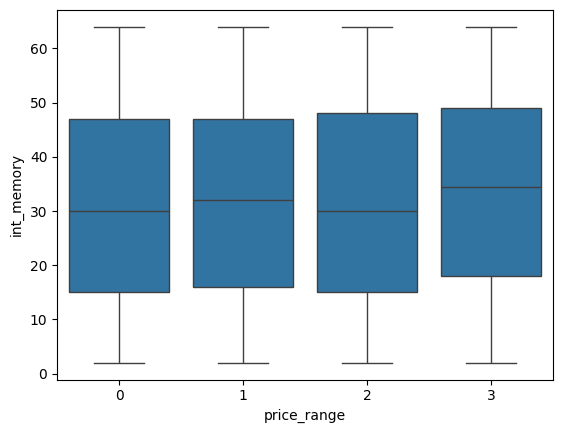

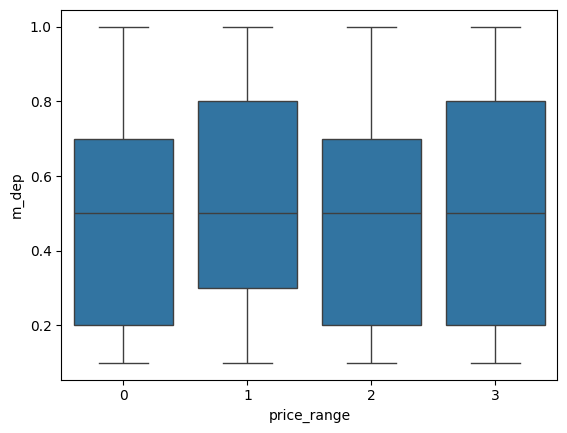

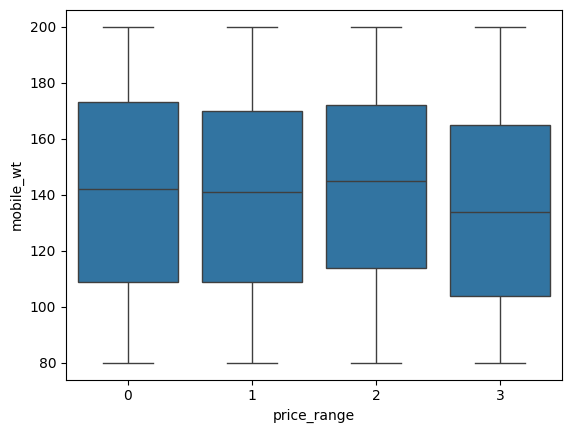

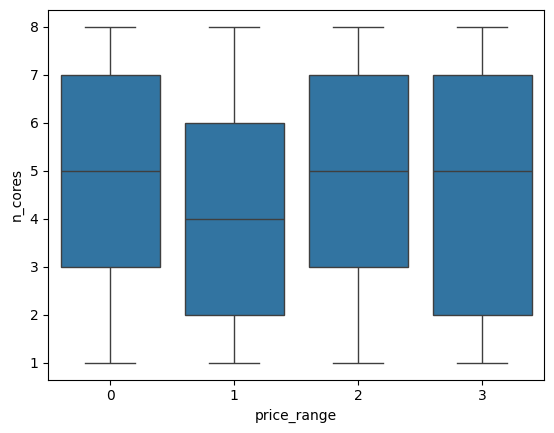

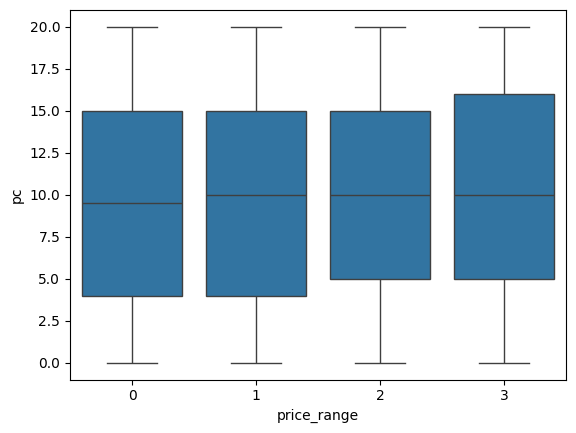

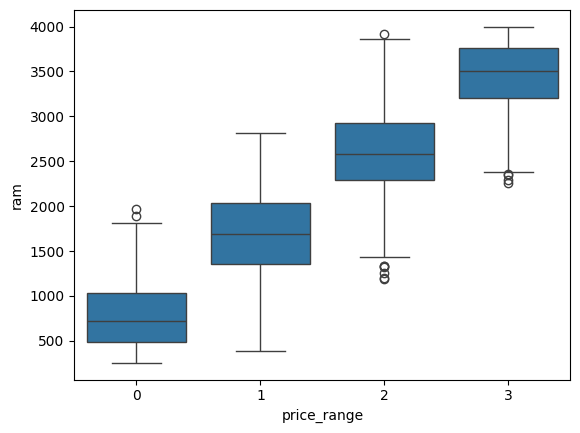

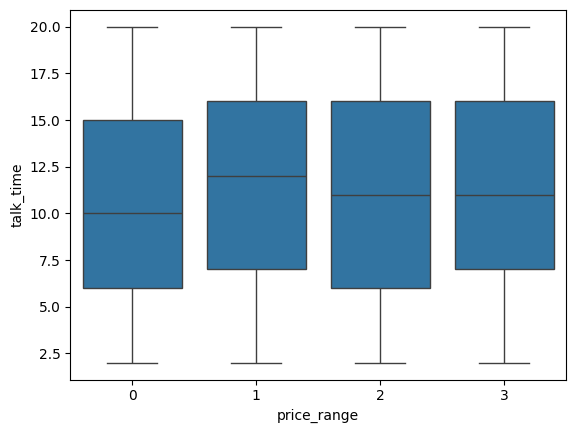

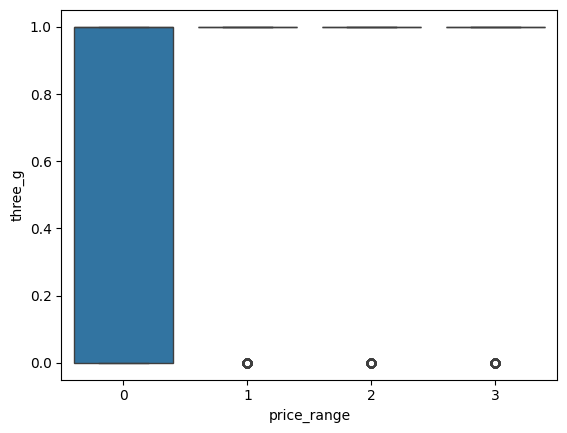

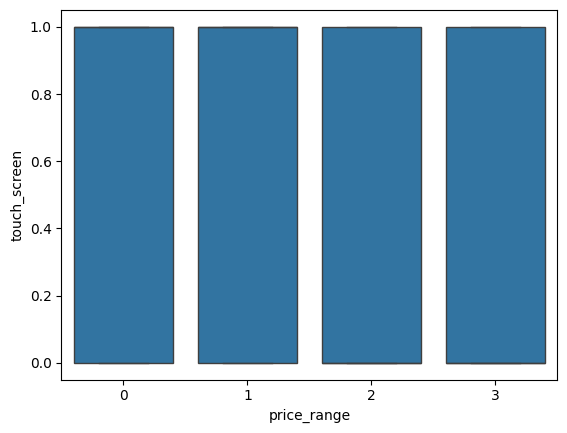

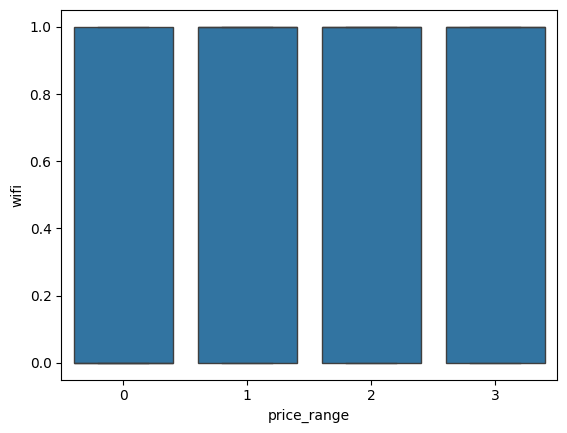

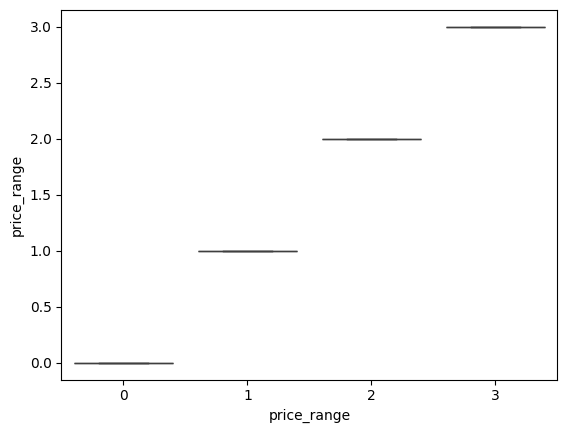

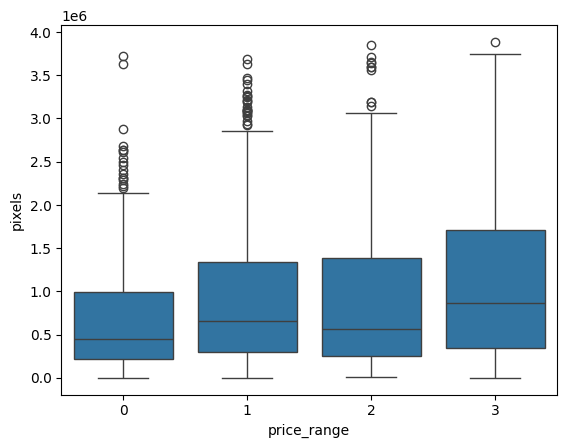

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt
for i in data.columns:
    sns.boxplot(data=data,x='price_range', y=i)
    plt.show()


<Axes: >

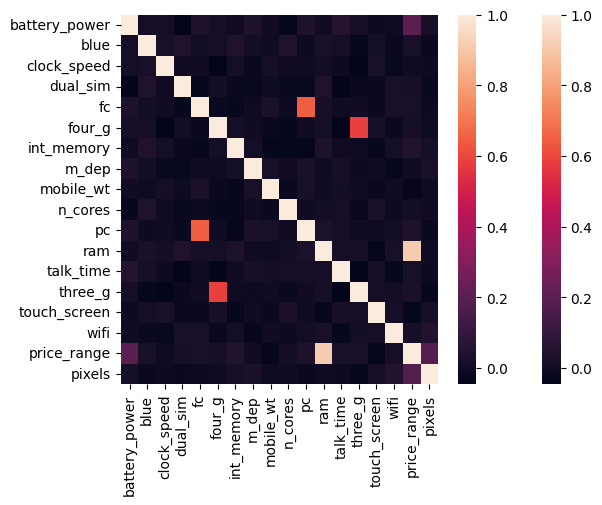

In [27]:
sns.heatmap(data.corr())
data['pixels']=data['px_height']*data['px_width']
data=data.drop(['px_height','px_width'],axis=1)
sns.heatmap(data.corr())

In [ ]:
#outiliers for extremes #we can plot using scatter

In [28]:
X = data.drop(['price_range'], axis = 1)
y = data['price_range']
X.shape

(2000, 17)

In [30]:
#scaling x
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_scaled=scaler.fit_transform(X)

In [31]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2)

In [33]:
x_train.shape

(1600, 17)

## Logistic-regression

In [34]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [36]:
Y_pred_test=model.predict(x_test)
Y_pred_train=model.predict(x_train)


In [40]:
#stats
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,Y_pred_test))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93        95
           1       0.90      0.83      0.86       104
           2       0.87      0.85      0.86       110
           3       0.90      0.95      0.92        91

    accuracy                           0.89       400
   macro avg       0.89      0.90      0.89       400
weighted avg       0.89      0.89      0.89       400



<Axes: >

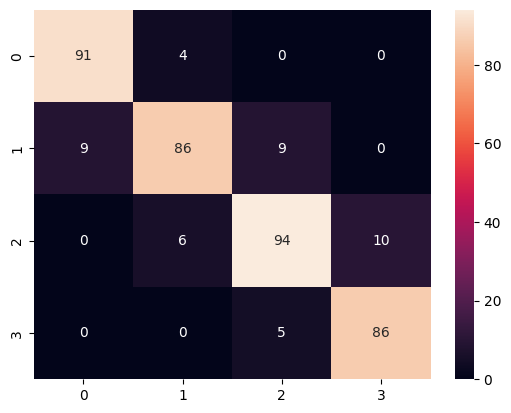

In [42]:
sns.heatmap(confusion_matrix(y_test,Y_pred_test),annot=True)

In [43]:
print(classification_report(y_train,Y_pred_train))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       405
           1       0.89      0.88      0.88       396
           2       0.91      0.83      0.87       390
           3       0.93      0.98      0.95       409

    accuracy                           0.92      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.92      0.92      0.91      1600



## Random forest

In [47]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [45]:
clfr=RandomForestClassifier(n_estimators=300)
clfr.fit(x_train,y_train)

RandomForestClassifier(n_estimators=300)

In [48]:
y_pred=clfr.predict(x_test)
print(accuracy_score(y_true=y_test,y_pred=y_pred))
print(classification_report(y_pred=y_pred,y_true=y_test))

0.875
              precision    recall  f1-score   support

           0       0.89      0.96      0.92        95
           1       0.88      0.78      0.83       104
           2       0.83      0.86      0.84       110
           3       0.91      0.91      0.91        91

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.87       400



<Axes: >

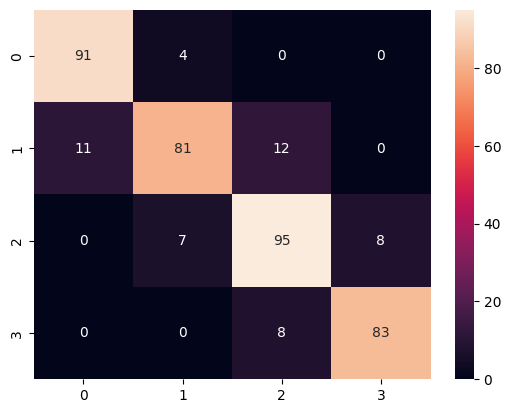

In [49]:
sns.heatmap(confusion_matrix(y_pred=y_pred,y_true=y_test),annot=True)

In [54]:
feature_importance=pd.DataFrame({'Feature':X.columns,'Score':clfr.feature_importances_}).sort_values(by='Score',ascending=False)
feature_importance

,Feature,Score
11,ram,0.525746
0,battery_power,0.082649
16,pixels,0.080055
8,mobile_wt,0.045784
6,int_memory,0.040367
12,talk_time,0.034394
10,pc,0.032712
2,clock_speed,0.030987
4,fc,0.028556
7,m_dep,0.027696


<Axes: xlabel='Feature', ylabel='Score'>

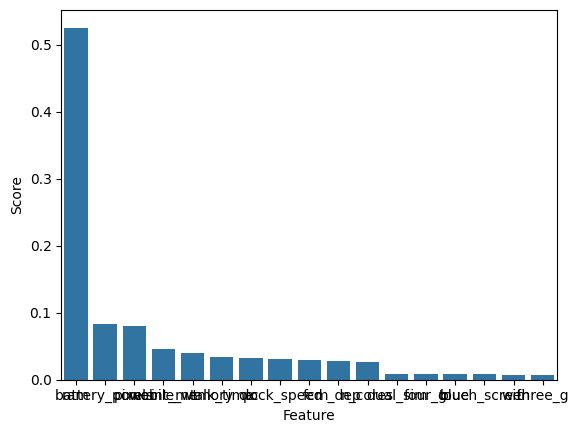

In [57]:
sns.barplot(x=feature_importance['Feature'],y=feature_importance['Score'],data=feature_importance)

## Decision tree

In [60]:
model=DecisionTreeClassifier(max_depth=6)
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=6)

In [61]:
Y_pred_test=model.predict(x_test)
Y_pred_train=model.predict(x_train)

In [62]:
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=6)

In [63]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,Y_pred_test))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90        95
           1       0.81      0.76      0.79       104
           2       0.80      0.77      0.79       110
           3       0.84      0.96      0.89        91

    accuracy                           0.84       400
   macro avg       0.84      0.85      0.84       400
weighted avg       0.84      0.84      0.84       400



<Axes: >

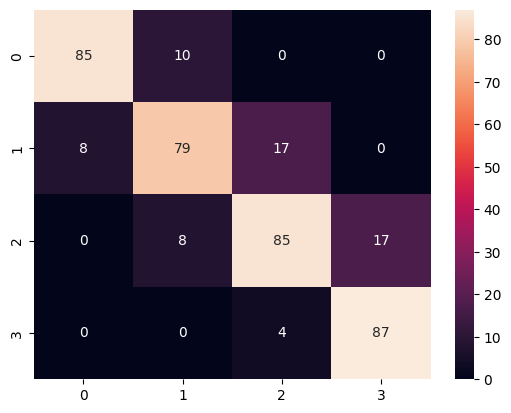

In [64]:
sns.heatmap(confusion_matrix(y_test,Y_pred_test),annot=True)

In [65]:
#cross-validation
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(model, param_grid = {'max_depth': (5, 30), 'max_leaf_nodes': (10, 100)}, scoring = 'accuracy', cv = 5, verbose = 24)
grid.fit(x_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5; 1/4] START max_depth=5, max_leaf_nodes=10..............................
[CV 1/5; 1/4] END max_depth=5, max_leaf_nodes=10;, score=0.769 total time=   0.0s
[CV 2/5; 1/4] START max_depth=5, max_leaf_nodes=10..............................
[CV 2/5; 1/4] END max_depth=5, max_leaf_nodes=10;, score=0.784 total time=   0.0s
[CV 3/5; 1/4] START max_depth=5, max_leaf_nodes=10..............................
[CV 3/5; 1/4] END max_depth=5, max_leaf_nodes=10;, score=0.750 total time=   0.0s
[CV 4/5; 1/4] START max_depth=5, max_leaf_nodes=10..............................
[CV 4/5; 1/4] END max_depth=5, max_leaf_nodes=10;, score=0.781 total time=   0.0s
[CV 5/5; 1/4] START max_depth=5, max_leaf_nodes=10..............................
[CV 5/5; 1/4] END max_depth=5, max_leaf_nodes=10;, score=0.816 total time=   0.0s
[CV 1/5; 2/4] START max_depth=5, max_leaf_nodes=100.............................
[CV 1/5; 2/4] END max_depth=5, max_leaf_node

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(max_depth=6),
             param_grid={'max_depth': (5, 30), 'max_leaf_nodes': (10, 100)},
             scoring='accuracy', verbose=24)

In [66]:
y_pred_test = grid.predict(x_test)
y_pres_train = grid.predict(x_train)
# Evaluation metrics for test

print('Classification Report for Decision Tree (Test set)= ')
print(classification_report(y_test, y_pred_test))

Classification Report for Decision Tree (Test set)= 
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        95
           1       0.86      0.80      0.83       104
           2       0.81      0.80      0.80       110
           3       0.86      0.92      0.89        91

    accuracy                           0.86       400
   macro avg       0.86      0.87      0.87       400
weighted avg       0.86      0.86      0.86       400



In [ ]:
#we can do xgb boost

              precision    recall  f1-score   support

           0       0.91      0.96      0.93        95
           1       0.90      0.83      0.86       104
           2       0.87      0.85      0.86       110
           3       0.90      0.95      0.92        91

    accuracy                           0.89       400
   macro avg       0.89      0.90      0.89       400
weighted avg       0.89      0.89      0.89       400



<Axes: >

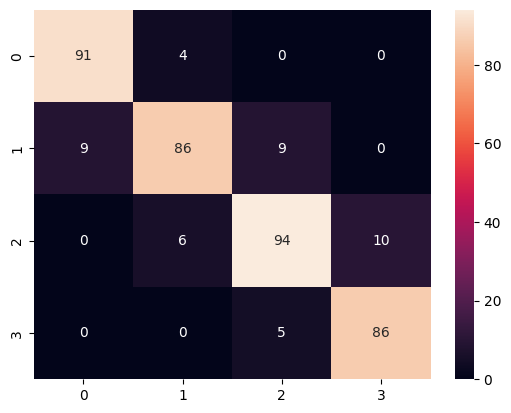

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
pca=PCA(n_components=3)
model=make_pipeline(LogisticRegression())
model.fit(x_train,y_train)
Y_pred_test=model.predict(x_test)
Y_pred_train=model.predict(x_train)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,Y_pred_test))
sns.heatmap(confusion_matrix(y_test,Y_pred_test),annot=True)

              precision    recall  f1-score   support

           0       0.24      0.26      0.25        95
           1       0.28      0.29      0.29       104
           2       0.31      0.25      0.28       110
           3       0.19      0.21      0.20        91

    accuracy                           0.26       400
   macro avg       0.26      0.25      0.25       400
weighted avg       0.26      0.26      0.26       400



c:\Users\sivar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


<Axes: >

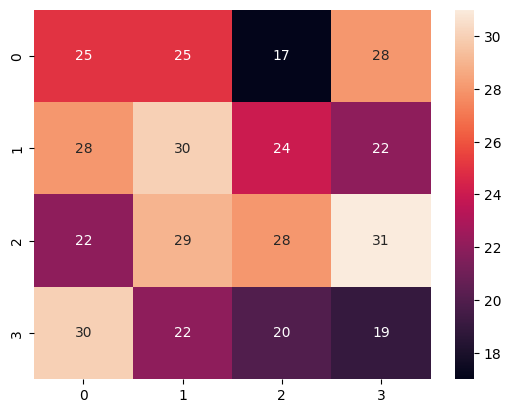

In [69]:
from sklearn.cluster import KMeans
model=KMeans(n_clusters=4)
model.fit(x_train,y_train)
Y_pred_test=model.predict(x_test)
Y_pred_train=model.predict(x_train)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,Y_pred_test))
sns.heatmap(confusion_matrix(y_test,Y_pred_test),annot=True)
#clustering is worst this is classification

              precision    recall  f1-score   support

           0       0.20      0.18      0.19        95
           1       0.23      0.25      0.24       104
           2       0.27      0.25      0.26       110
           3       0.20      0.23      0.22        91

    accuracy                           0.23       400
   macro avg       0.23      0.23      0.23       400
weighted avg       0.23      0.23      0.23       400



c:\Users\sivar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


<Axes: >

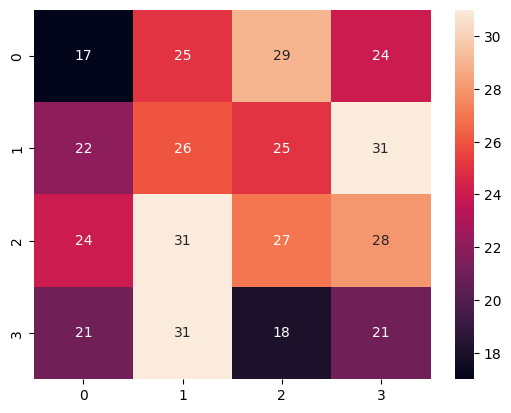

In [70]:
from sklearn.mixture import BayesianGaussianMixture
model=BayesianGaussianMixture(n_components=4)
model.fit(x_train,y_train)
Y_pred_test=model.predict(x_test)
Y_pred_train=model.predict(x_train)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,Y_pred_test))
sns.heatmap(confusion_matrix(y_test,Y_pred_test),annot=True)